In [11]:
# reading the retail data set
retail <- read.csv("OnlineRetail.csv")

## Structure of `retail` dataset

In [12]:
str(retail)

'data.frame':	541909 obs. of  8 variables:
 $ InvoiceNo  : chr  "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : int  6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: chr  "12/1/2010 8:26" "12/1/2010 8:26" "12/1/2010 8:26" "12/1/2010 8:26" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : int  17850 17850 17850 17850 17850 17850 17850 17850 17850 13047 ...
 $ Country    : chr  "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


In [13]:
df <- data.frame(retail)

## Data Cleaning Plan

- Handle missing Customer IDs:
  - Replace with `"Unknown"`
  - When I loaded that into `Microsoft SQL Server`, making primary key as `CustomerID` it throwed me an error, so it concluded that some of it's data are missing.

In [14]:
any(is.na(df$CustomerID)) 
df$CustomerID[is.na(df$CustomerID)] <- "Unknown"
any(is.na(df$CustomerID)) 

[1] TRUE

[1] FALSE

In [15]:
any(is.na(df)) # We have no missing values in our data frame

[1] FALSE

# COUNTRY NAME NORMALIZATION SCRIPT

---

## Purpose
Clean and standardize country names in a dataset using the **countrycode** library.  
Handles exceptions, islands, and regional/unspecified categories separately.

---

## Steps
1. Convert country names to ISO3 codes using `countrycode`.  
2. Preserve known abbreviations or special entries (e.g. `USA`, `RSA`, `EIRE`).  
3. Group island-related and unspecified entries into categories.  
4. Split dataset into:
   - **specified_country** → valid countries  
   - **other_category** → islands, unspecified, or regional groups  

---

## Libraries
- `countrycode`  
- `dplyr`


In [16]:
library(countrycode)
library(dplyr) 
# Normalize the country name, and there are other's like islands specify them in different category

countryName <- function(country) { # since I don't like writing all code at single line
    countrycode(country, origin = "country.name", destination = "iso3c")
}

exception <- c("USA", "RSA", "EIRE", "Unspecified", "European Community", "Channel Islands")

# c("USA", "RSA", "EIRE", "Unspecified", "European Community", "Channel Islands"), these weird syntax drive me nuts its just inline condition condition ? smt else : smth
df$Country <- ifelse(df$Country %in% exception, df$Country, countryName(df$Country))

unique(df$Country)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“Some values were not matched unambiguously: Channel Islands, EIRE, European Community, RSA, Unspecified
”


[1] "GBR"                "FRA"                "AUS"               
 [4] "NLD"                "DEU"                "NOR"               
 [7] "EIRE"               "CHE"                "ESP"               
[10] "POL"                "PRT"                "ITA"               
[13] "BEL"                "LTU"                "JPN"               
[16] "ISL"                "Channel Islands"    "DNK"               
[19] "CYP"                "SWE"                "AUT"               
[22] "ISR"                "FIN"                "BHR"               
[25] "GRC"                "HKG"                "SGP"               
[28] "LBN"                "ARE"                "SAU"               
[31] "CZE"                "CAN"                "Unspecified"       
[34] "BRA"                "USA"                "European Community"
[37] "MLT"                "RSA"

## QUANTITY COLUMN VALIDATION AND CLEANUP

---

## Purpose
Ensure that the `Quantity` column reflects valid, non-negative values.  
In sales or transaction data, negative quantities are usually data entry errors or
sign inversions that don’t make physical sense (an item sold cannot be negative).

---

## Steps
1. Convert all `Quantity` values to their **absolute values** using `abs()`.  
   This corrects any negative entries.

2. Check for entries where `Quantity` is **exactly zero**.  
   - If no zero values are found, it indicates all transactions have valid, nonzero quantities.

3. Verify that the total quantity (sum of all `Quantity` values) may be larger than the number of rows in the dataset (`nrow(df)`),  
   since multiple items can be sold per transaction.

---

## Notes
- Negative quantities are converted to positive values to maintain data consistency.  
- Zero quantities would indicate potential data quality issues, but none were found in this dataset.


In [17]:
df$Quantity <- abs(df$Quantity) # assuming it a type and conversting to a absolute value 
paste("Quantity with exact zero: ",  sum(df[df$Quantity == 0]), " Quantity with non negative: ", sum(df$Quantity)) # we expect larger number than the dim of df, cause more than one items can be sold

[1] "Quantity with exact zero:  0  Quantity with non negative:  6145512"

## Checking for StockCode

In [18]:
any(is.na(df$StockCode)) # We don't have any nulls in stock code.
any(df$StockCode <= 0)

[1] FALSE

[1] FALSE

# UNIT PRICE ERROR CHECK

---

## Purpose
Validate and clean the `UnitPrice` column to remove invalid or nonsensical values.

---

## Steps
1. Identify entries with `UnitPrice == 0` (2515 items).  
   - Attempt to impute using similar products if possible.  
   - Otherwise, drop these rows since their impact is minimal.

2. Remove rows with negative `UnitPrice` values.  
   - Found 2 cases with description *"Adjust bad debt"*, which were excluded.

---

## Result
All remaining entries now have valid positive `UnitPrice` values.


In [19]:
df <- df[df$UnitPrice > 0, ]
any(df$UnitPrice <= 0)
dim(df)

[1] FALSE

[1] 539392      8

## Product Description

In [20]:
check <- df[df$Description == "", ]
any(is.na(df$Description))
# I don't think we have an missing value over there

[1] FALSE

## Working with date 
    . From raw data, dates are given to us as a character, so we are converting it to date object.

In [21]:
df$InvoiceDate <- as.Date(df$InvoiceDate, format = "%m/%d/%Y") # %m represents month in decimal, %m represents month in decimal and %y represents the year 
str(df) # if we look at the str we should see the Date object, 

'data.frame':	539392 obs. of  8 variables:
 $ InvoiceNo  : chr  "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : int  6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: Date, format: "2010-12-01" "2010-12-01" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : chr  "17850" "17850" "17850" "17850" ...
 $ Country    : chr  "GBR" "GBR" "GBR" "GBR" ...


## Exploratory Data Analysis

In [22]:
summary(df)
unique(df$Country)

  InvoiceNo          StockCode         Description           Quantity       
 Length:539392      Length:539392      Length:539392      Min.   :    1.00  
 Class :character   Class :character   Class :character   1st Qu.:    1.00  
 Mode  :character   Mode  :character   Mode  :character   Median :    3.00  
                                                          Mean   :   10.88  
                                                          3rd Qu.:   10.00  
                                                          Max.   :80995.00  
  InvoiceDate           UnitPrice         CustomerID          Country         
 Min.   :2010-12-01   Min.   :    0.00   Length:539392      Length:539392     
 1st Qu.:2011-03-28   1st Qu.:    1.25   Class :character   Class :character  
 Median :2011-07-20   Median :    2.08   Mode  :character   Mode  :character  
 Mean   :2011-07-04   Mean   :    4.67                                        
 3rd Qu.:2011-10-19   3rd Qu.:    4.13                            

[1] "GBR"                "FRA"                "AUS"               
 [4] "NLD"                "DEU"                "NOR"               
 [7] "EIRE"               "CHE"                "ESP"               
[10] "POL"                "PRT"                "ITA"               
[13] "BEL"                "LTU"                "JPN"               
[16] "ISL"                "Channel Islands"    "DNK"               
[19] "CYP"                "SWE"                "AUT"               
[22] "ISR"                "FIN"                "BHR"               
[25] "GRC"                "HKG"                "SGP"               
[28] "LBN"                "ARE"                "SAU"               
[31] "CZE"                "CAN"                "Unspecified"       
[34] "BRA"                "USA"                "European Community"
[37] "MLT"                "RSA"

## Most sold products

 Description        TotalItemSOldInGroup
 Length:5           Min.   : 40469      
 Class :character   1st Qu.: 49589      
 Mode  :character   Median : 56247      
                    Mean   : 92164      
                    3rd Qu.:152527      
                    Max.   :161990      

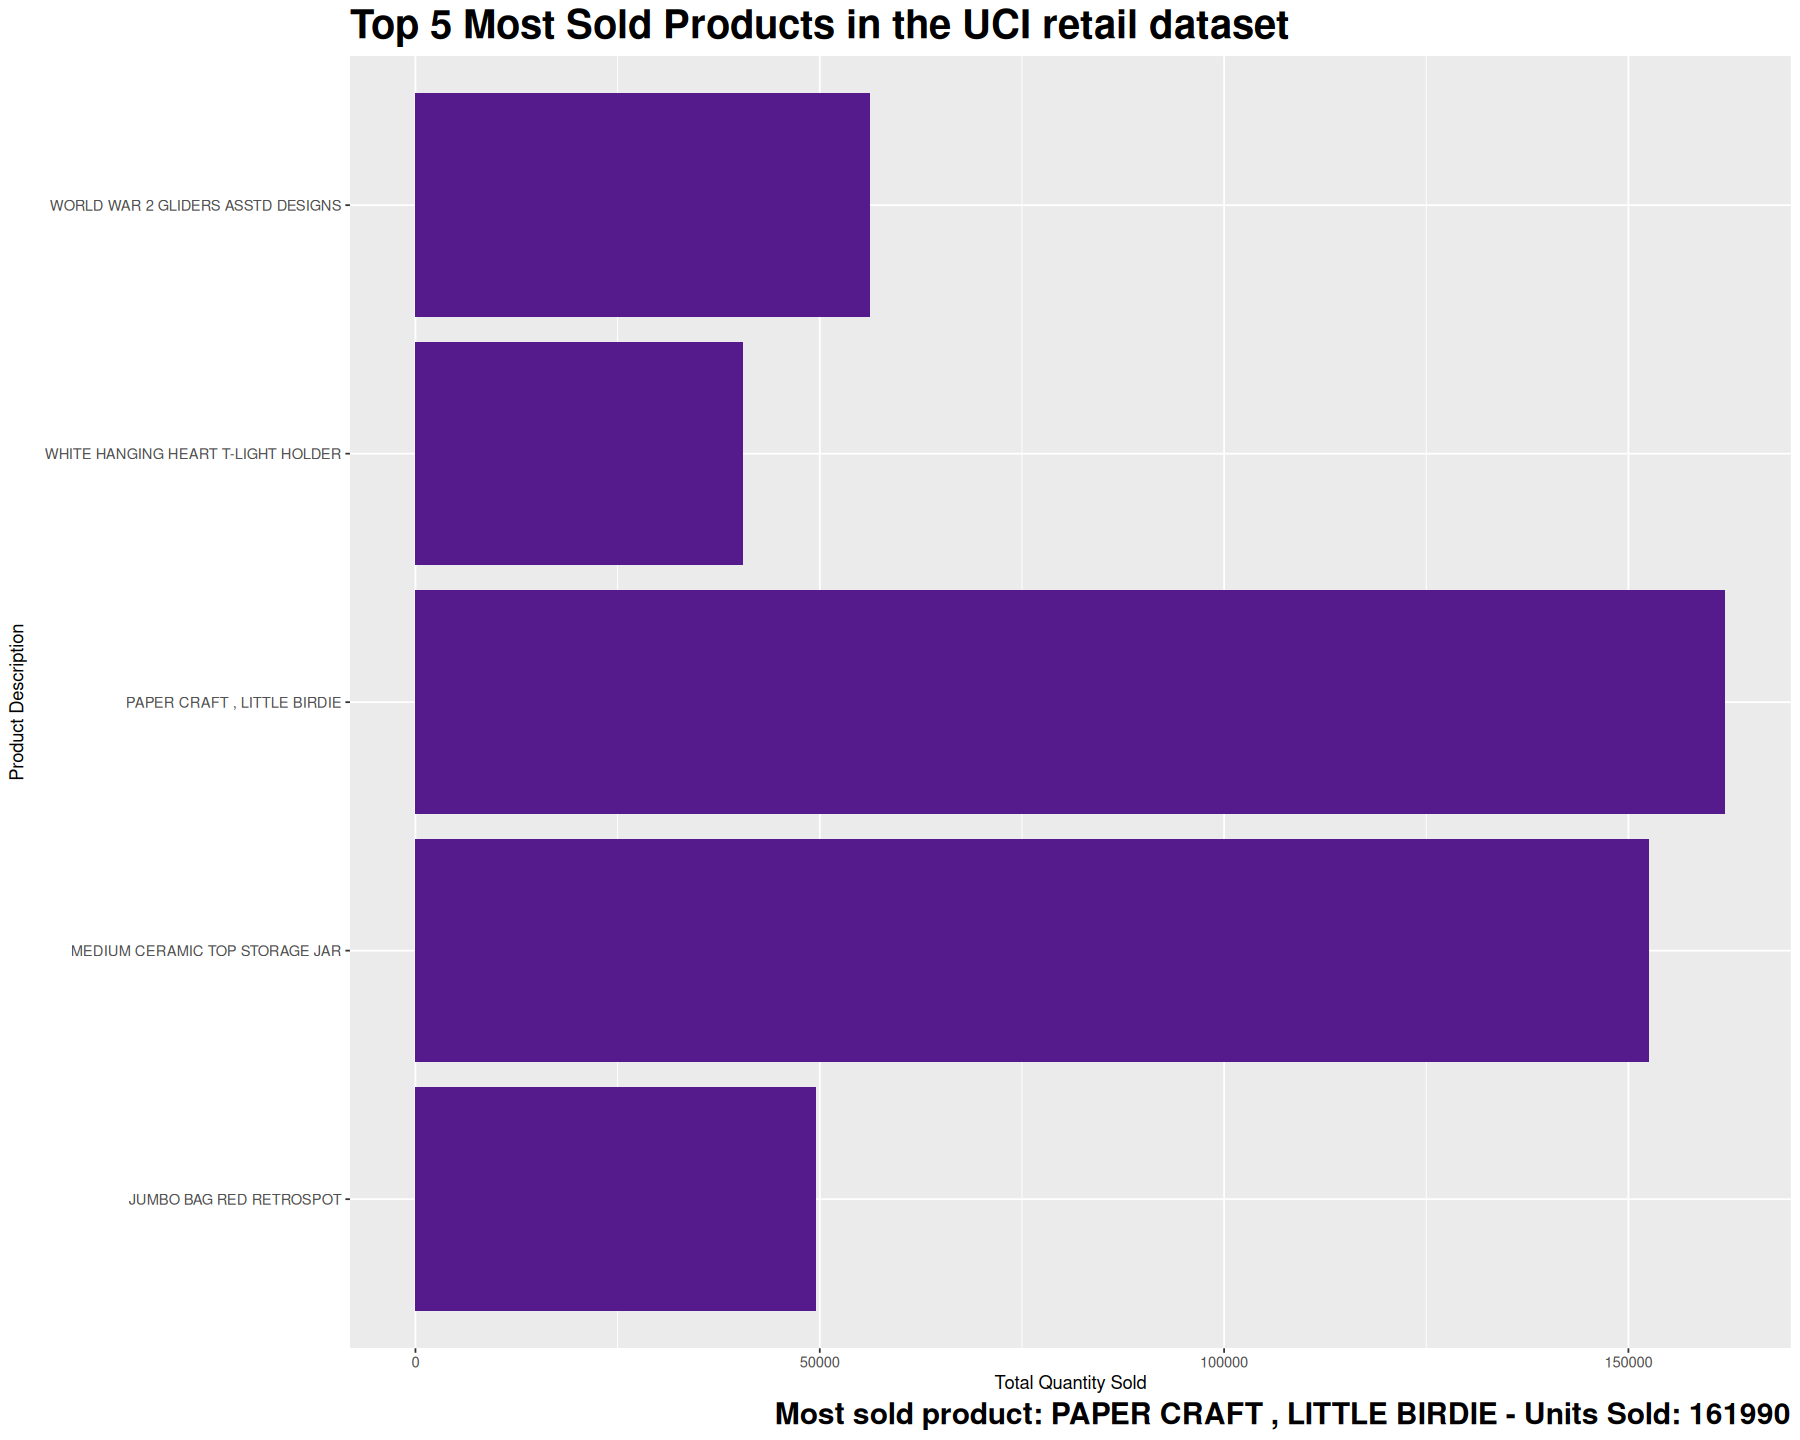

In [23]:
library(ggplot2)
options(repr.plot.width = 15, repr.plot.height = 12)
grouped_products <- group_by(df, Description) # takes and existing tbl and converts into a grouped tbl where opreations ar eperformed by group.
summarized_by_product <- summarise(grouped_products, TotalItemSOldInGroup = sum(Quantity, na.rm = TRUE)) # na.ram = TRUE means ignore missing values
# summarise forms a new table, where each group from group_by becomes one row
# /* Here, we have a large df like lets say
#    Product Qty
#    p1      1
#    p2      2
#    p1      1
#    group_by greats group, and sum does the summing of those, with na.rm ignoring values
#    p1      (1, 1)
#    p2      (2)
# */
ordered_by_product_sold <- summarized_by_product[order(summarized_by_product$TotalItemSOldInGroup, decreasing=TRUE), ] # why order because it gives the indices
top_5_items_sold <- head(ordered_by_product_sold, 5)

# stat="identity" meaning the value of the chart are directly determined by y-values, by default stat="count" uses height as frequency 
ggplot(top_5_items_sold, aes(x=Description, y=TotalItemSOldInGroup)) + geom_bar(stat = "identity", fill="purple4") +
labs(
    title = "Top 5 Most Sold Products in the UCI retail dataset",                             
    x = "Product Description",                          
    y = "Total Quantity Sold",
    caption = paste("Most sold product:", top_5_items_sold$Description[1], 
                    "- Units Sold:", top_5_items_sold$TotalItemSOldInGroup[1]) 
) +  coord_flip() + theme(
   plot.caption = element_text(size = 18, face = "bold"),
   plot.title = element_text(size=24, face="bold"),
) # it flips the barchart for better visibility
summary(top_5_items_sold)

## Number of sales over the years
    . Learning with trying
    . First I grouped by months and then realized that, it grouped let's say `month 1` of both the year and whole data is wrong
    . What we can do now is group by year first and then month and compare both the line plots.

    . First filter, by years, and then extract `months` and then make a line plot.
    . The above idea is rejected because the year 2010 has only 1 month of data.

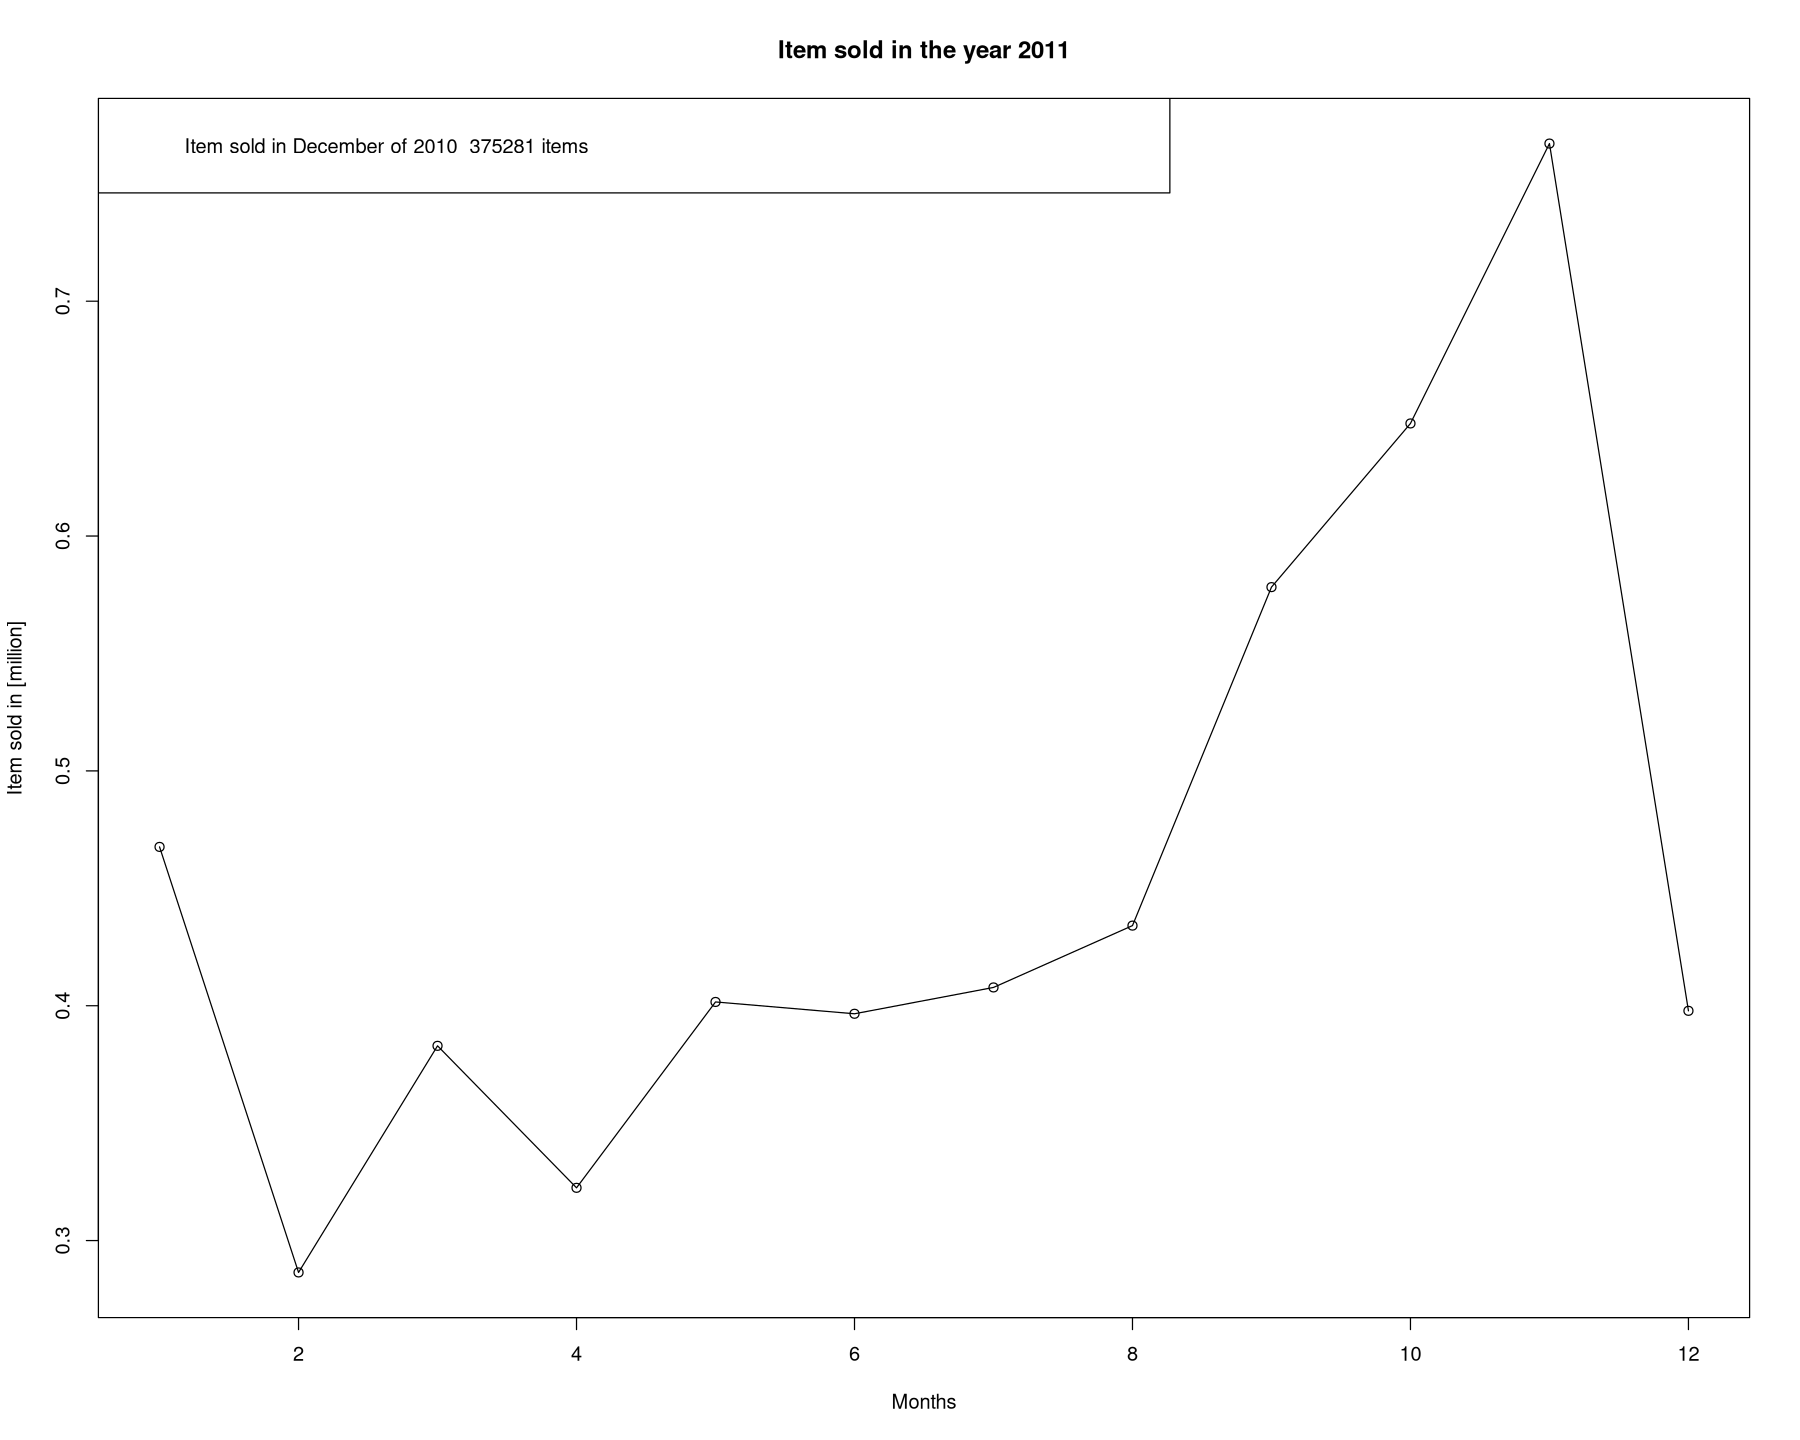

In [134]:
## I am new to this whole thing, but I know with practise I will leran to do things in better way, but now I will group that like done before.

library(dplyr)
library(ggplot2)

df$Year <- format(df$InvoiceDate, "%Y") # group by years okay 2010 and 2011 based on our data 
group_by_years <- group_by(df, Year) # It holds data which are grouped by years

group_by_month <- function(data_frame) {
    data_frame$Month <- format(data_frame$InvoiceDate, "%m") # adding a "month" column
    grouped_by_date <- group_by(data_frame, Month)
    # so far so good verified that 2010 has only 1 month data which is 12, I don't trust R
    # okay since the year 2010 has only 1 month of data we can't plot line graph and compare it like I did in my PID controller project. What we can do is create a bar chart for one 
    # and line chart for another year

    summ <- summarise(grouped_by_date, TotalItemSOldInGroup = sum(Quantity, na.rm = TRUE)) # I mean dataset is huge I expect it the item sold to be in more
    return (summ)
}
y10 <- filter(group_by_years, Year == "2010")
y11 <- filter(group_by_years, Year == "2011")
# Items sold in each month of the year
y10m <- group_by_month(y10)
y11m <- group_by_month(y11)

plot(y11m$Month, (y11m$TotalItemSOldInGroup/10^6), type="o", main ="Item sold in the year 2011", ylab="Item sold in [million]", xlab="Months")
# since 2010 has data for only one month
legend_label <- paste("Item sold in December of 2010 ", y10m$TotalItemSOldInGroup, "items")
legend("topleft", legend = c(legend_label))     